In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install tensorboardX rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 17.7 MB/s eta 0:00:00


In [4]:
import os
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
torch.manual_seed(8) # for reproduce


import time
import numpy as np
import gc
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/')
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
# from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
#then import my own modules
from AttentiveFP import Fingerprint, Fingerprint_viz, save_smiles_dicts, get_smiles_dicts, get_smiles_array, moltosvg_highlight

/usr/local/lib/python3.10/dist-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [5]:
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import QED
from rdkit.Chem import rdMolDescriptors, MolSurf
from rdkit.Chem.Draw import SimilarityMaps
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.cm as cm
import matplotlib
import seaborn as sns; sns.set_style("darkgrid")
from IPython.display import SVG, display
import sascorer
import itertools
from sklearn.metrics import r2_score
import scipy

number of all smiles:  40
number of successfully processed smiles:  40


<ipython-input-6-1857cd6244db>:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


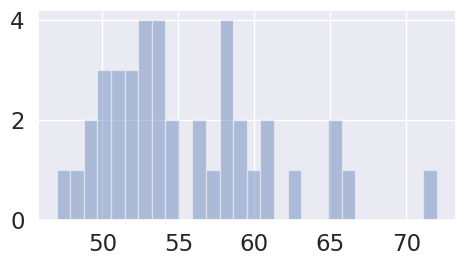

In [6]:
task_name = 'Calx'
tasks = ['H3K4','H3K4ac','H3K4me1','H3K4me2','H3K4me3','H3K9me3','H3R2me2a','H3R2me2s']
#tasks = ['H3K4']

raw_filename = '/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/data/cal_abs.csv'
feature_filename = raw_filename.replace('.csv','.pickle')
filename = raw_filename.replace('.csv','')
prefix_filename = raw_filename.split('/')[-1].replace('.csv','')
smiles_tasks_df = pd.read_csv(raw_filename)

smilesList = smiles_tasks_df.SMILES.values
print("number of all smiles: ",len(smilesList))
atom_num_dist = []
remained_smiles = []
canonical_smiles_list = []
for smiles in smilesList:
    try:
        mol = Chem.MolFromSmiles(smiles)
        atom_num_dist.append(len(mol.GetAtoms()))
        remained_smiles.append(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
    except:
        print(smiles)
        pass
print("number of successfully processed smiles: ", len(remained_smiles))
smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["SMILES"].isin(remained_smiles)]
smiles_tasks_df['cano_smiles'] =canonical_smiles_list

plt.figure(figsize=(5, 3))
sns.set(font_scale=1.5)
ax = sns.distplot(atom_num_dist, bins=28, kde=False)
plt.tight_layout()
# plt.savefig("atom_num_dist_"+prefix_filename+".png",dpi=200)
plt.show()
plt.close()


In [7]:
random_seed = 888
start_time = str(time.ctime()).replace(':','-').replace(' ','_')

batch_size = 500
epochs = 300

p_dropout= 0.5
fingerprint_dim = 280

weight_decay = 4.9 # also known as l2_regularization_lambda
learning_rate = 3.4
radius = 2
T = 2
per_task_output_units_num = 1 # for regression model
output_units_num = len(tasks) * per_task_output_units_num


In [8]:
if os.path.isfile(feature_filename):
    feature_dicts = pickle.load(open(feature_filename, "rb" ))
else:
    feature_dicts = save_smiles_dicts(smilesList,filename)
# feature_dicts = get_smiles_dicts(smilesList)
remained_df = smiles_tasks_df[smiles_tasks_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]
uncovered_df = smiles_tasks_df.drop(remained_df.index)
uncovered_df

,Host,SMILES,H3K4,H3K4ac,H3K4me1,H3K4me2,H3K4me3,H3K9me3,H3R2me2a,H3R2me2s,cano_smiles


In [9]:
test_df = remained_df.sample(frac=1/10, random_state=random_seed) # test set
training_data = remained_df.drop(test_df.index) # training data

# get the stats of the seen dataset (the training data)
# which will be used to noramlize the dataset.
columns = ['Task','Mean','Standard deviation', 'Mean absolute deviation','ratio']
mean_list=[]
std_list=[]
mad_list=[]
ratio_list=[]
for task in tasks:
    mean = training_data[task].mean()
    mean_list.append(mean)
    std = training_data[task].std()
    std_list.append(std)
    # Replacing deprecated mad() with alternative calculation
    mad = (training_data[task] - mean).abs().mean()
    mad_list.append(mad)
    ratio_list.append(std/mad)
    training_data[task+'_normalized'] = (training_data[task] - mean) / std
    test_df[task+'_normalized'] = (test_df[task] - mean) / std


# training data is further divided into validation set and train set
valid_df = training_data.sample(frac=1/9, random_state=random_seed) # validation set
train_df = training_data.drop(valid_df.index) # train set
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

list_of_tuples = list(zip(tasks, mean_list, std_list, mad_list, ratio_list))
stats  = pd.DataFrame(list_of_tuples, columns = columns)
stats


,Task,Mean,Standard deviation,Mean absolute deviation,ratio
0,H3K4,0.997827,2.201376,1.661535,1.324905
1,H3K4ac,1.606715,2.310738,1.596225,1.447627
2,H3K4me1,-0.164643,1.599003,1.343511,1.190167
3,H3K4me2,-1.801159,1.767244,1.487743,1.187870
4,H3K4me3,-1.961956,1.631520,1.366697,1.193769
5,H3K9me3,-1.023703,1.722166,1.446267,1.190766
6,H3R2me2a,-0.641051,1.689075,1.408499,1.199202
7,H3R2me2s,0.258545,1.752485,1.354402,1.293918


<ipython-input-10-f41d0bae5161>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(x, bins=28, kde=False)


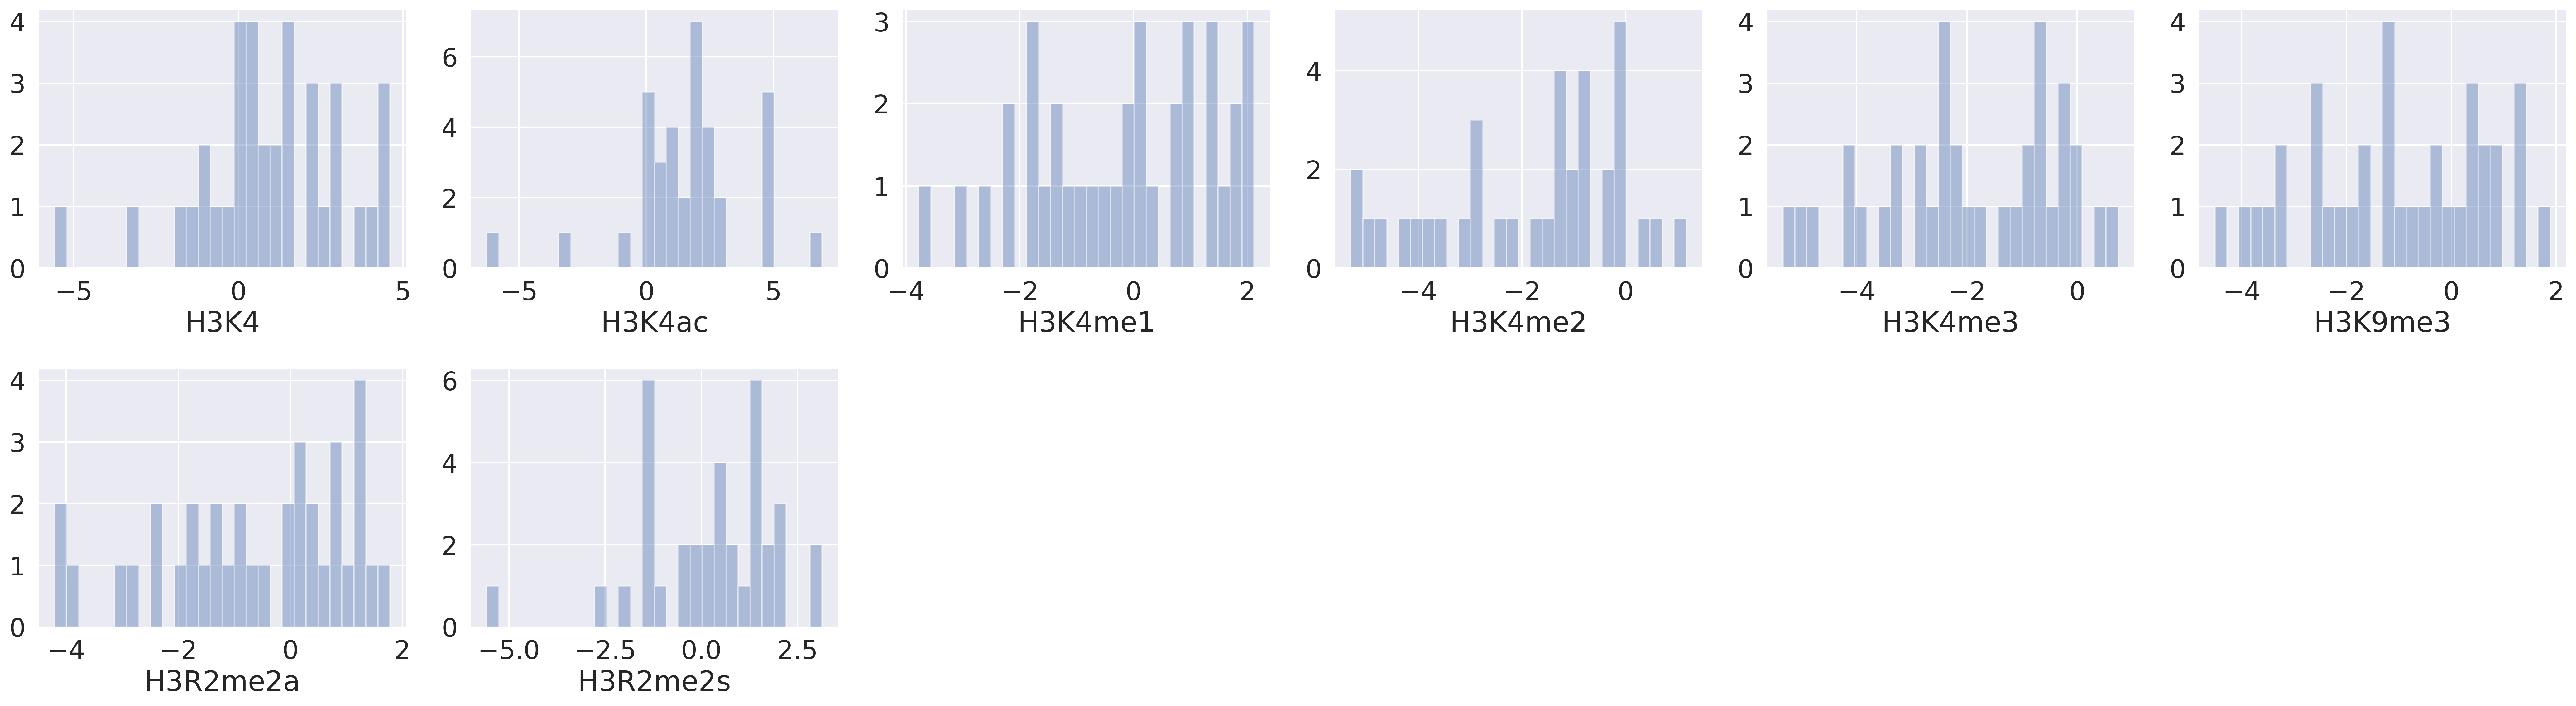

In [10]:
# check the value distribution of different tasks
plt.figure(figsize=(28, 8),dpi=300)
gs = gridspec.GridSpec(2, 6)
sns.set(font_scale=1.8)
for i, task in enumerate(tasks):
    plt.subplot(gs[(i)])
    x = pd.Series(training_data[task].values, name=task)
    ax = sns.distplot(x, bins=28, kde=False)
    plt.tight_layout()
plt.show()
plt.close()

<ipython-input-11-d69123f7546f>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(x, bins=28, kde=False)


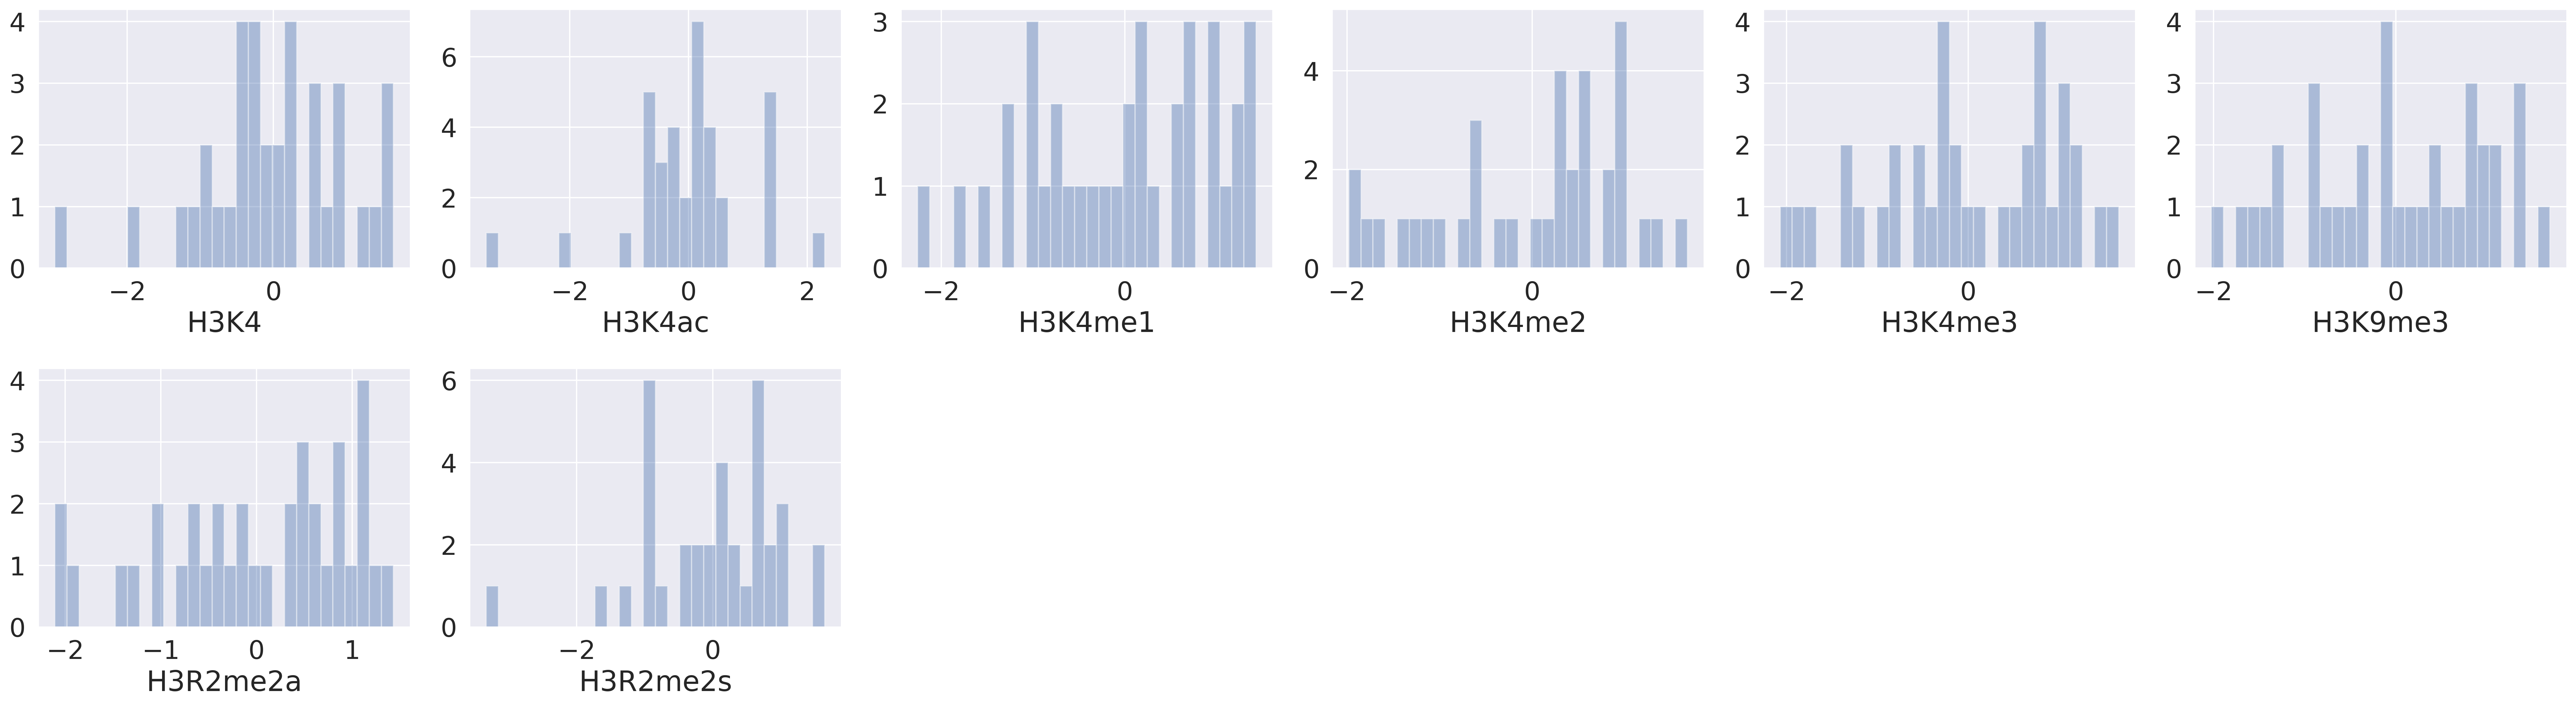

In [11]:
# check the distribution after normalization (should be the same)

plt.figure(figsize=(28, 8),dpi=300)
gs = gridspec.GridSpec(2, 6)
sns.set(font_scale=1.8)
for i, task in enumerate(tasks):
    plt.subplot(gs[(i)])
    x = pd.Series(training_data[task+"_normalized"].values, name=task)
    ax = sns.distplot(x, bins=28, kde=False)
    plt.tight_layout()
plt.show()
plt.close()

In [12]:
x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([canonical_smiles_list[8]],feature_dicts)
num_atom_features = x_atom.shape[-1]
num_bond_features = x_bonds.shape[-1]
# loss_function = nn.L1Loss()
loss_function = nn.MSELoss()
model = Fingerprint(radius, T, num_atom_features, num_bond_features,
            fingerprint_dim, output_units_num, p_dropout)
model.cuda()

optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)
# optimizer = optim.SGD(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)

# tensorboard = SummaryWriter(log_dir="runs/"+start_time+"_"+prefix_filename+"_"+str(fingerprint_dim)+"_"+str(p_dropout))

model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(params)
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data.shape)


1681411
atom_fc.weight torch.Size([280, 39])
atom_fc.bias torch.Size([280])
neighbor_fc.weight torch.Size([280, 49])
neighbor_fc.bias torch.Size([280])
GRUCell.0.weight_ih torch.Size([840, 280])
GRUCell.0.weight_hh torch.Size([840, 280])
GRUCell.0.bias_ih torch.Size([840])
GRUCell.0.bias_hh torch.Size([840])
GRUCell.1.weight_ih torch.Size([840, 280])
GRUCell.1.weight_hh torch.Size([840, 280])
GRUCell.1.bias_ih torch.Size([840])
GRUCell.1.bias_hh torch.Size([840])
align.0.weight torch.Size([1, 560])
align.0.bias torch.Size([1])
align.1.weight torch.Size([1, 560])
align.1.bias torch.Size([1])
attend.0.weight torch.Size([280, 280])
attend.0.bias torch.Size([280])
attend.1.weight torch.Size([280, 280])
attend.1.bias torch.Size([280])
mol_GRUCell.weight_ih torch.Size([840, 280])
mol_GRUCell.weight_hh torch.Size([840, 280])
mol_GRUCell.bias_ih torch.Size([840])
mol_GRUCell.bias_hh torch.Size([840])
mol_align.weight torch.Size([1, 560])
mol_align.bias torch.Size([1])
mol_attend.weight torch.S

In [13]:
def train(model, dataset, optimizer, loss_function):
    model.train()
    np.random.seed(epoch)
    valList = np.arange(0,dataset.shape[0])
    #shuffle them
    np.random.shuffle(valList)
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i+batch_size]
        batch_list.append(batch)

    for counter, batch in enumerate(batch_list):
        batch_df = dataset.loc[batch,:]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom),torch.Tensor(x_bonds),torch.cuda.LongTensor(x_atom_index),torch.cuda.LongTensor(x_bond_index),torch.Tensor(x_mask))

        optimizer.zero_grad()
        loss = 0.0
        for i,task in enumerate(tasks):
            y_pred = mol_prediction[:, i]
            y_val = batch_df[task+"_normalized"].values
            loss += loss_function(y_pred, torch.Tensor(y_val).squeeze())*ratio_list[i]**2
        loss.backward()
        optimizer.step()

def eval(model, dataset):
    model.eval()
    eval_MAE_list = {}
    eval_MSE_list = {}
    y_val_list = {}
    y_pred_list = {}
    for i,task in enumerate(tasks):
        y_pred_list[task] = np.array([])
        y_val_list[task] = np.array([])
        eval_MAE_list[task] = np.array([])
        eval_MSE_list[task] = np.array([])

    valList = np.arange(0,dataset.shape[0])
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i+batch_size]
        batch_list.append(batch)
    for counter, batch in enumerate(batch_list):
        batch_df = dataset.loc[batch,:]
        smiles_list = batch_df.cano_smiles.values

        batch_df = dataset.loc[batch,:]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom),torch.Tensor(x_bonds),torch.cuda.LongTensor(x_atom_index),torch.cuda.LongTensor(x_bond_index),torch.Tensor(x_mask))

        for i,task in enumerate(tasks):
            y_pred = mol_prediction[:, i]
            y_val = batch_df[task+"_normalized"].values

            MAE = F.l1_loss(y_pred, torch.Tensor(y_val).squeeze(), reduction='none')
            MSE = F.mse_loss(y_pred, torch.Tensor(y_val).squeeze(), reduction='none')
            y_pred_list[task] = np.concatenate([y_pred_list[task], y_pred.cpu().detach().numpy()])
            y_val_list[task] = np.concatenate([y_val_list[task], y_val])
            eval_MAE_list[task] = np.concatenate([eval_MAE_list[task],MAE.data.squeeze().cpu().numpy()])
            eval_MSE_list[task] = np.concatenate([eval_MSE_list[task],MSE.data.squeeze().cpu().numpy()])
#     r2_score_list = [r2_score(y_val_list[task], y_pred_list[task]) for task in tasks]
    eval_MAE_normalized = np.array([eval_MAE_list[task].mean() for i, task in enumerate(tasks)])
    eval_MAE = np.multiply(eval_MAE_normalized,np.array(std_list))
    eval_MSE_normalized = np.array([eval_MSE_list[task].mean() for i, task in enumerate(tasks)])
    eval_MSE = np.multiply(eval_MSE_normalized,np.array(std_list))

    return eval_MAE_normalized, eval_MAE, eval_MSE_normalized, eval_MSE #, r2_score_list


In [24]:
best_param ={}
best_param["train_epoch"] = 0
best_param["valid_epoch"] = 0
best_param["train_MSE_normalized"] = 9e8
best_param["valid_MSE_normalized"] = 9e8
for epoch in range(300):
    train(model, train_df, optimizer, loss_function)
    train_MAE_normalized, train_MAE, train_MSE_normalized, train_MSE = eval(model, train_df)
    valid_MAE_normalized, valid_MAE, valid_MSE_normalized, valid_MSE, = eval(model, valid_df)
    print("EPOCH:\t"+str(epoch)+'\n'\
#         +"train_MAE_normalized: "+str(train_MAE_normalized)+'\n'\
#         +"valid_MAE_normalized: "+str(valid_MAE_normalized)+'\n'\
        +"train_MAE"+":"+"\n"+str(train_MAE)+'\n'\
        +"valid_MAE"+":"+"\n"+str(valid_MAE)+'\n'\

        +"train_MSE_normalized_mean: "+str(train_MSE_normalized.mean())+'\n'\
        +"valid_MSE_normalized_mean: "+str(valid_MSE_normalized.mean())+'\n'\
#         +"train_MSE_normalized: "+str(train_MSE_normalized)+'\n'\
#         +"valid_MSE_normalized: "+str(valid_MSE_normalized)+'\n'\
        )
    if train_MSE_normalized.mean() < best_param["train_MSE_normalized"]:
        best_param["train_epoch"] = epoch
        best_param["train_MSE_normalized"] = train_MSE_normalized.mean()
    if valid_MSE_normalized.mean() < best_param["valid_MSE_normalized"]:
        best_param["valid_epoch"] = epoch
        best_param["valid_MSE_normalized"] = valid_MSE_normalized.mean()
        if valid_MSE_normalized.mean() < 0.40:
             torch.save(model, '/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(epoch)+'.pt')
#     if (epoch - best_param["train_epoch"] >10) and (epoch - best_param["valid_epoch"] >18):
#         break



EPOCH:	0
train_MAE:
[0.25508476 0.28918623 0.20243385 0.23864066 0.16952454 0.21041579
 0.15563543 0.23109006]
valid_MAE:
[1.33418215 1.48312471 0.92201313 0.67615144 0.70900376 1.14254578
 0.79847021 0.74698264]
train_MSE_normalized_mean: 0.02119518164029799
valid_MSE_normalized_mean: 0.4083566889808026

EPOCH:	1
train_MAE:
[0.24673656 0.29259218 0.2089248  0.2497404  0.16712584 0.20663692
 0.16890506 0.25922392]
valid_MAE:
[1.33434598 1.53027584 0.90963309 0.6046971  0.69473967 1.12344923
 0.73485563 0.72323163]
train_MSE_normalized_mean: 0.022777349021351867
valid_MSE_normalized_mean: 0.4010835021103958

EPOCH:	2
train_MAE:
[0.17453487 0.19565075 0.1830614  0.23112184 0.14251423 0.17144478
 0.14097089 0.22743627]
valid_MAE:
[1.36190797 1.51975588 0.96746976 0.69060645 0.75889802 1.17631715
 0.8359307  0.78117182]
train_MSE_normalized_mean: 0.016222583172396554
valid_MSE_normalized_mean: 0.43214438119866827

EPOCH:	3
train_MAE:
[0.24412523 0.24371265 0.19748121 0.26090245 0.14750415 

mu, alpha, homo, lumo, gap, r2, zpve, u0, u298, h298, g298, cv

In [25]:
# evaluate model
best_model = torch.load('/content/drive/MyDrive/Colab Notebooks/Drug_Project/AttentiveFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(best_param["valid_epoch"])+'.pt')

test_MAE_normalized, test_MAE, test_MSE_normalized, test_MSE, = eval(best_model, test_df)
print("best epoch:"+str(best_param["valid_epoch"])+'\n'\
    +"test_MAE"+":"+"\n"+str(test_MAE)+'\n'\
    +"test_MSE_normalized_mean: "+str(test_MSE_normalized.mean())+'\n'\
    )

best epoch:150
test_MAE:
[1.59087811 1.47101937 1.00366651 1.36427147 1.19583988 0.87635864
 1.90904537 1.10396842]
test_MSE_normalized_mean: 0.7043364431265218

